# Garment production

## Executive summary



## Introduction

## Library and data load

In [2]:
import pandas as pd
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_auc_score, roc_curve, f1_score, precision_score, recall_score, precision_recall_curve
from sklearn.model_selection import KFold,StratifiedKFold, cross_validate, train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [46]:
# load dataset
df = pd.read_csv('../datasets/garments_worker_productivity.csv')

## EDA

### Data types

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   quarter                1197 non-null   object 
 2   department             1197 non-null   object 
 3   day                    1197 non-null   object 
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    1197 non-null   float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: f

Meaning of features:

date: Date in MM-DD-YYYY.  
day: Day of the Week.  
quarter: A portion of the month. A month was divided into four quarters.  
department:	Associated department with the instance: sweing or finishing    
team_no: Associated team number with the instance.  
no_of_workers: Number of workers in each team.  
no_of_style_change:	Number of changes in the style of a particular product.  
targeted_productivity: Targeted productivity set by the Authority for each team for each day.  
smv: Standard Minute Value, it is the allocated time for a task.  
wip: Work in progress. Includes the number of unfinished items for products.  
over_time: Represents the amount of overtime by each team in minutes (as the sum of all their members).  
incentive: Represents the amount of financial incentive (in BDT) that enables or motivates a particular course of action.  
idle_time: The amount of time during which the production was interrupted due to several reasons.  
idle_men: The number of workers who were idle due to production interruption.  
actual_productivity: The actual % of productivity that was delivered by the workers. It ranges from 0-1.  

### Data overview and cleanning

In [59]:
df.drop_duplicates()
df.head(20)

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,0.0,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382
5,1/1/2015,Quarter1,sweing,Thursday,7,0.80,25.90,984.0,6720,38,0.0,0,0,56.0,0.800125
6,1/1/2015,Quarter1,finishing,Thursday,2,0.75,3.94,0.0,960,0,0.0,0,0,8.0,0.755167
7,1/1/2015,Quarter1,sweing,Thursday,3,0.75,28.08,795.0,6900,45,0.0,0,0,57.5,0.753683
8,1/1/2015,Quarter1,sweing,Thursday,2,0.75,19.87,733.0,6000,34,0.0,0,0,55.0,0.753098
9,1/1/2015,Quarter1,sweing,Thursday,1,0.75,28.08,681.0,6900,45,0.0,0,0,57.5,0.750428


In [61]:
df.describe()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,6.426901,0.729632,15.062172,687.228070,4567.460317,38.210526,0.730159,0.369256,0.150376,34.609858,0.735091
std,3.463963,0.097891,10.943219,1514.582341,3348.823563,160.182643,12.709757,3.268987,0.427848,22.197687,0.174488
min,1.000000,0.070000,2.900000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,3.000000,0.700000,3.940000,0.000000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650307
50%,6.000000,0.750000,15.260000,586.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.773333
75%,9.000000,0.800000,24.260000,1083.000000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850253
max,12.000000,0.800000,54.560000,23122.000000,25920.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,1.120437


There are some rows with a non-integer number of workers.

In [66]:
np.equal(df['no_of_workers']*2, np.round(df['no_of_workers']*2)).all()

np.True_

We verify that all non-integer 'no_of_workers' are x.5; We consider this like a part-time worker.

There are some strange values for 'actual_productivity' greater than 1.

In [67]:
df[df['actual_productivity']>1]

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
337,1/20/2015,Quarter3,finishing,Tuesday,5,0.70,4.15,0.0,1440,0,0.0,0,0,8.0,1.033570
437,1/26/2015,Quarter4,finishing,Monday,3,0.75,3.94,0.0,1800,0,0.0,0,0,10.0,1.059621
456,1/27/2015,Quarter4,sweing,Tuesday,2,0.75,22.52,1635.0,6840,119,0.0,0,0,57.0,1.000230
457,1/27/2015,Quarter4,sweing,Tuesday,3,0.75,22.52,1299.0,6840,119,0.0,0,0,57.0,1.000230
477,1/28/2015,Quarter4,sweing,Wednesday,2,0.80,22.52,1559.0,6840,90,0.0,0,0,57.0,1.000230
478,1/28/2015,Quarter4,sweing,Wednesday,3,0.80,22.52,1350.0,6840,113,0.0,0,0,57.0,1.000230
498,1/29/2015,Quarter5,sweing,Thursday,2,0.80,22.52,1416.0,6840,113,0.0,0,0,57.0,1.000230
518,1/31/2015,Quarter5,sweing,Saturday,3,0.80,22.52,1136.0,6960,113,0.0,0,0,58.0,1.000457
519,1/31/2015,Quarter5,sweing,Saturday,2,0.80,22.52,1397.0,6840,113,0.0,0,0,57.0,1.000230
542,2/1/2015,Quarter1,finishing,Sunday,8,0.65,4.15,0.0,960,0,0.0,0,0,8.0,1.011562


In [83]:
df['date'] = pd.to_datetime(df['date'])

### Missing values

From describe we can see that the only missing values are in the feature wip, and these missings are only for department 'finishing'.

In [49]:
df[df['wip'].isna()].sort_values(by='department')

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
1196,3/11/2015,Quarter2,finishing,Wednesday,6,0.70,2.90,NaN,720,0,0.0,0,0,6.0,0.394722
838,2/18/2015,Quarter3,finishing,Wednesday,8,0.70,5.13,NaN,960,0,0.0,0,0,8.0,0.580000
837,2/18/2015,Quarter3,finishing,Wednesday,10,0.80,3.94,NaN,960,0,0.0,0,0,8.0,0.640250
836,2/18/2015,Quarter3,finishing,Wednesday,7,0.70,5.13,NaN,960,0,0.0,0,0,8.0,0.671875
833,2/18/2015,Quarter3,finishing,Wednesday,4,0.75,5.13,NaN,960,0,0.0,0,0,8.0,0.734646
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
384,1/22/2015,Quarter4,finishing,Thursday,2,0.70,3.94,NaN,15000,0,0.0,0,0,25.0,0.649662
383,1/22/2015,Quarter4,finishing,Thursday,1,0.70,3.94,NaN,15000,0,0.0,0,0,25.0,0.649662
382,1/22/2015,Quarter4,finishing,Thursday,4,0.75,4.30,NaN,9000,0,0.0,0,0,15.0,0.670216
401,1/24/2015,Quarter4,finishing,Saturday,12,0.70,4.08,NaN,1620,0,0.0,0,0,9.0,0.858586


We can see that all the NaN in wip are related with department 'finising'.

And there aren't 'wip' 0. The 0 'wip' is pretty common in industry, so the absense of 'wip' is odd. We assume that the NaN values are those that should be 0.

In [53]:
df['wip']=df['wip'].fillna(0)

Let's obseve that the 'finishing' was not a daily task, in fact: in january just one team in one day worked in finishing

In [92]:
finishing_monthly = df[df['department'] == 'finishing'] \
    .groupby(pd.Grouper(key='date', freq='ME')) \
    .size() \
    .reset_index(name='finishing_count')

finishing_monthly

,date,finishing_count
0,2015-01-31,1
1,2015-02-28,151
2,2015-03-31,97


In [93]:
sweing_monthly = df[df['department'] == 'sweing'] \
    .groupby(pd.Grouper(key='date', freq='ME')) \
    .size() \
    .reset_index(name='sweing_count')

sweing_monthly

,date,sweing_count
0,2015-01-31,307
1,2015-02-28,269
2,2015-03-31,115


In [125]:
df['department'].value_counts()

department
sweing        691
finishing     257
finishing     249
Name: count, dtype: int64

In [126]:
df['department'] = df['department'].str.strip()
df['department'].value_counts()

department
sweing       691
finishing    506
Name: count, dtype: int64

We introduce a ordinal categorical variable for actual productivity

In [127]:
df['prod_cat'] = pd.cut(
    df['actual_productivity'],
    bins=[0, 0.7, 0.9, float('inf')],
    labels=[1, 2, 3],
    right=False
)

In [128]:
summary = df.groupby(
    ['team', 'day', 'prod_cat']
).size().reset_index(name='count')

summary['prop'] = summary.groupby(['team','day'])['count'] \
                         .transform(lambda x: x/x.sum())

C:\Users\gabri\AppData\Local\Temp\ipykernel_31504\1907546767.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby(
C:\Users\gabri\AppData\Local\Temp\ipykernel_31504\1907546767.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary['prop'] = summary.groupby(['team','day'])['count'] \


### Plots

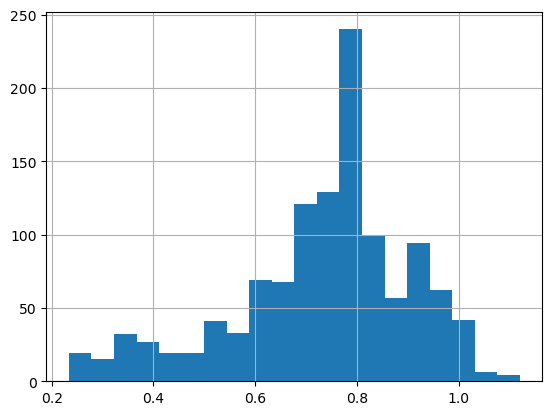

In [129]:
df['actual_productivity'].hist(bins=20);

In the productivity histogram, we can see a distribution center near 0.8. This value falls under our second productivity category, below the most desirable value.

<Axes: xlabel='department', ylabel='actual_productivity'>

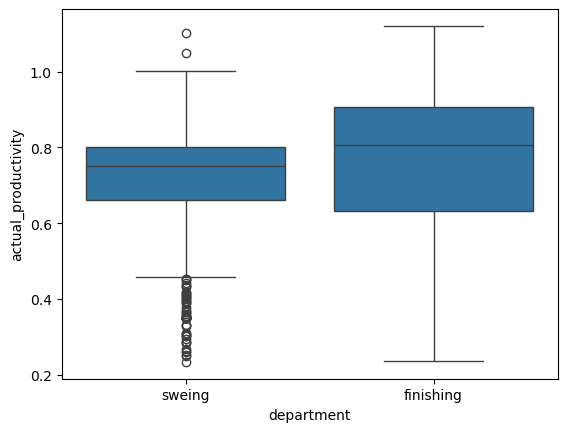

In [147]:
sns.boxplot(data=df, x='department', y='actual_productivity')

There is no significant difference between the actual productivity of sewing and finishing. It is worth mentioning the more homogeneous distribution in finishing, which is evident in the short distance between quartiles compared to the outliers present in sewing.

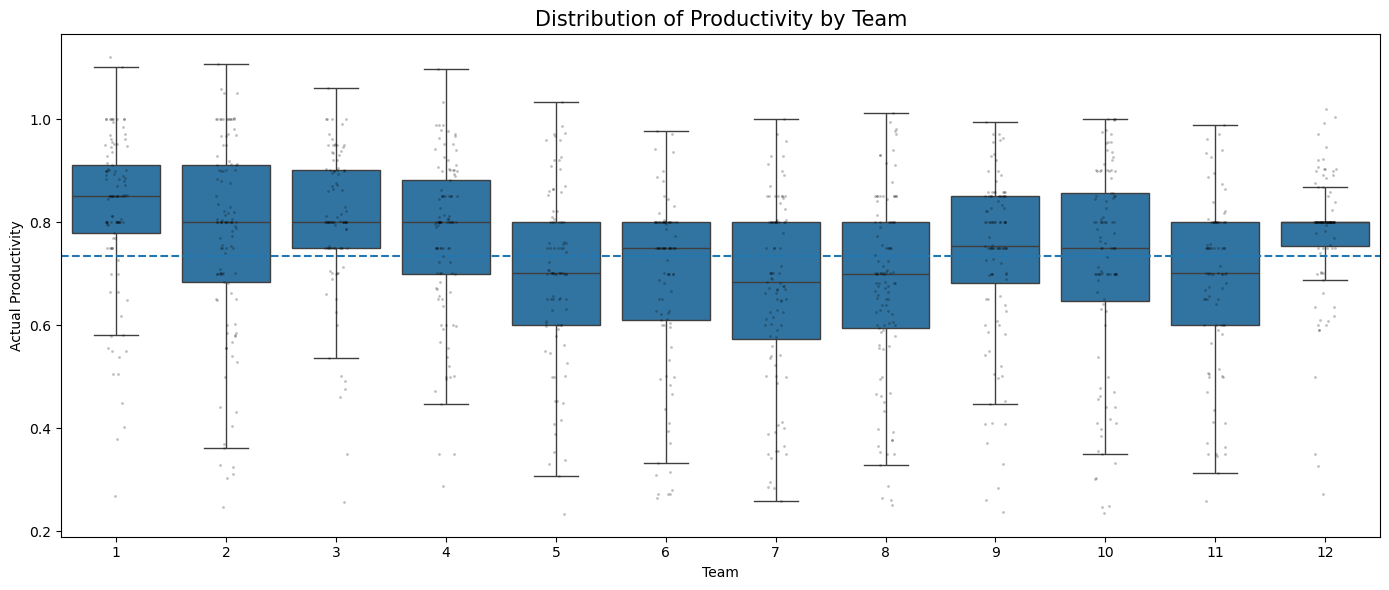

In [132]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

sns.boxplot(
    data=df,
    x='team',
    y='actual_productivity',
    showfliers=False
)

sns.stripplot(
    data=df,
    x='team',
    y='actual_productivity',
    color='black',
    alpha=0.25,
    size=2
)

# Línea de media global
global_mean = df['actual_productivity'].mean()
plt.axhline(global_mean, linestyle='--')

plt.title('Distribution of Productivity by Team', fontsize=15)
plt.xlabel('Team')
plt.ylabel('Actual Productivity')
plt.tight_layout()
plt.show()

In these boxplots, we can see that several teams have their mean productivity above the overall average, but all teams show a large IQR and several outliers.

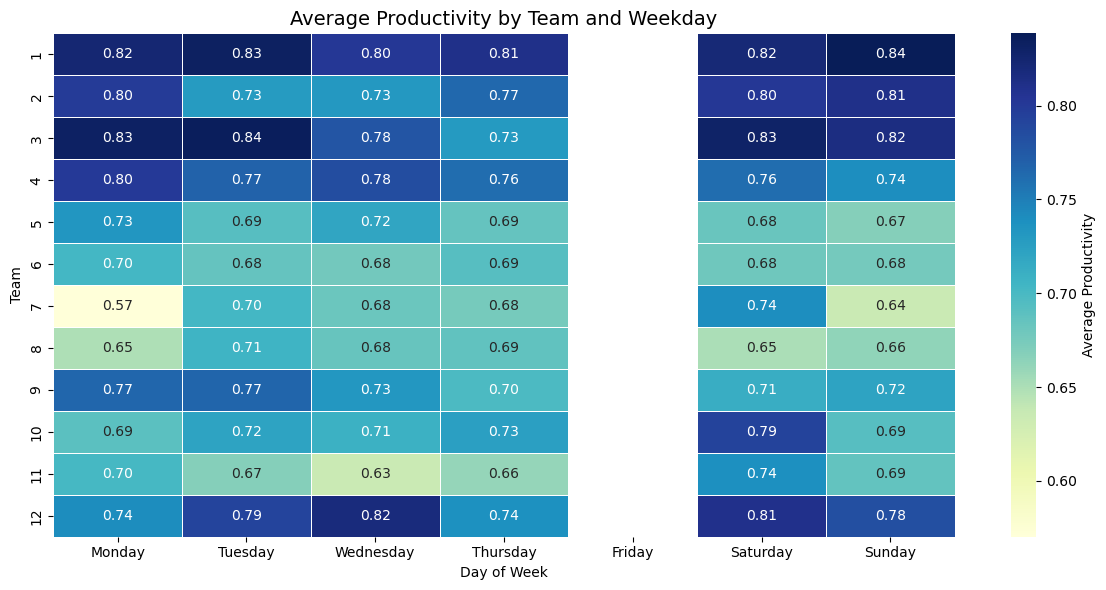

In [149]:
# Orden correcto de días
order_days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# Asegurar orden
df['day'] = pd.Categorical(df['day'],
                           categories=order_days,
                           ordered=True)

# Pivot ordenado
pivot = (
    df.groupby(['team','day'], observed=True)['actual_productivity']
      .mean()
      .unstack()
      .reindex(columns=order_days)
)

# Plot
plt.figure(figsize=(12,6))

sns.heatmap(
    pivot,
    cmap='YlGnBu',
    annot=True,        # muestra valores
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={'label': 'Average Productivity'}
)

plt.title('Average Productivity by Team and Weekday', fontsize=14)
plt.xlabel('Day of Week')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

This heatmap is another way to view the information already shown in the boxplots.

<Axes: xlabel='has_ot', ylabel='actual_productivity'>

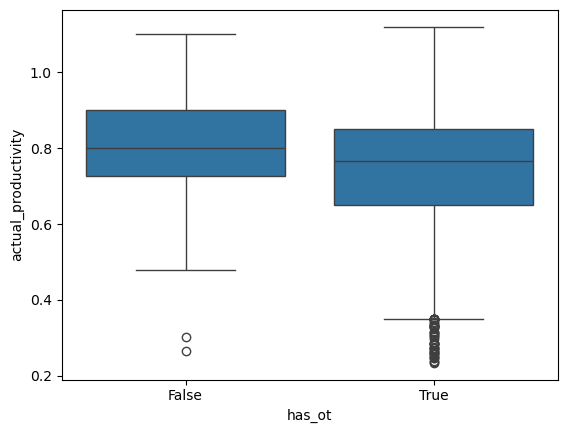

In [150]:
df['has_ot'] = df['over_time'] > 0

sns.boxplot(data=df,
            x='has_ot',
            y='actual_productivity');

The boxplots show that overtime does not lead to an increase in productivity.

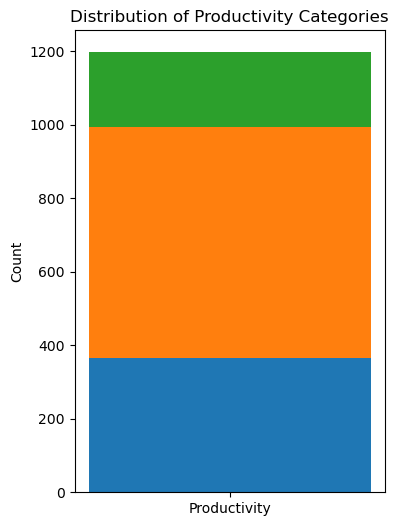

In [154]:
import matplotlib.pyplot as plt

counts = df['prod_cat'].value_counts().sort_index()

plt.figure(figsize=(4,6))

bottom = 0
for cat, value in counts.items():
    plt.bar('Productivity', value, bottom=bottom)
    bottom += value
    
ax.legend(title='Category')
plt.ylabel('Count')
plt.title('Distribution of Productivity Categories')
plt.show()

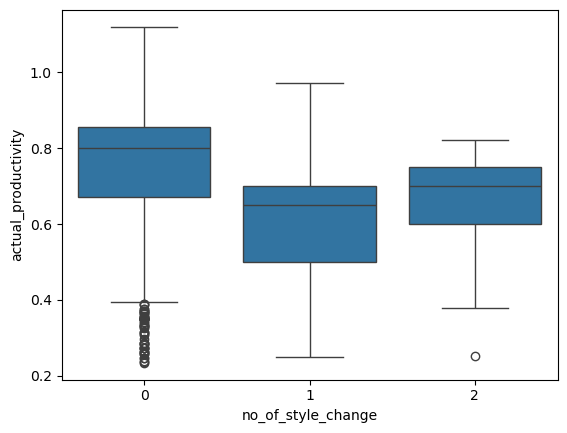

In [174]:
sns.boxplot(data=df, x='no_of_style_change', y='actual_productivity');

By the boxplots of actual productivity grouped by number of style changes, we can see that the style changes have no strong linear relation with productivity

<Axes: xlabel='smv', ylabel='actual_productivity'>

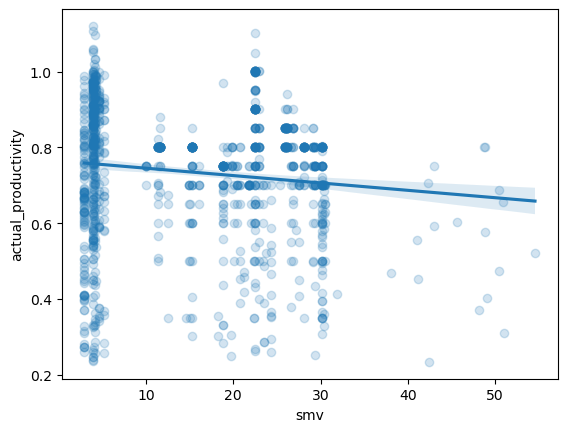

In [176]:
sns.regplot(data=df, x='smv', y='actual_productivity',
            scatter_kws={'alpha':0.2});

From the plot, we can see that there are typical SMV values instead of a continuous distribution.
The high heterogeneity in productivity shows that SMV is not enough to explain productivity, although it seems to have a negative correlation.

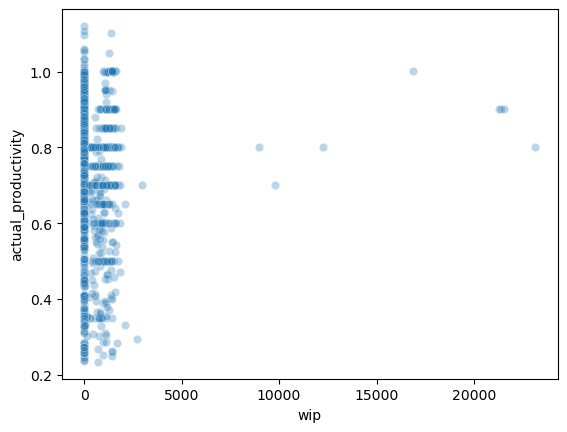

In [177]:
sns.scatterplot(data=df, x='wip', y='actual_productivity', alpha=0.3);

We apply a logarithmic scale for impove visualization.

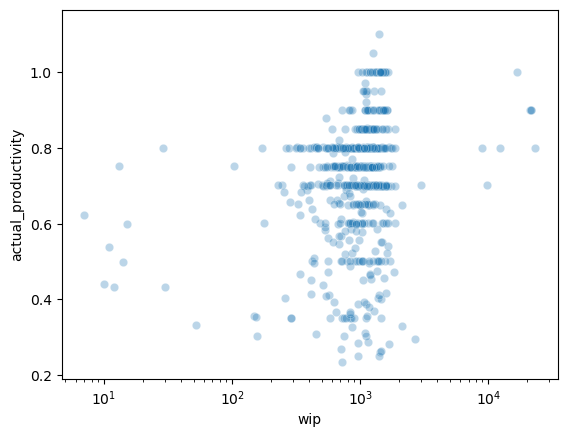

In [178]:
sns.scatterplot(data=df, x='wip', y='actual_productivity', alpha=0.3)
plt.xscale('log')

The distribution shows a slight positive association with productivity.
However, the relationship appears weak and the high dispersion suggests that WIP alone is not sufficient to explain productivity differences.

<Axes: xlabel='incentive', ylabel='actual_productivity'>

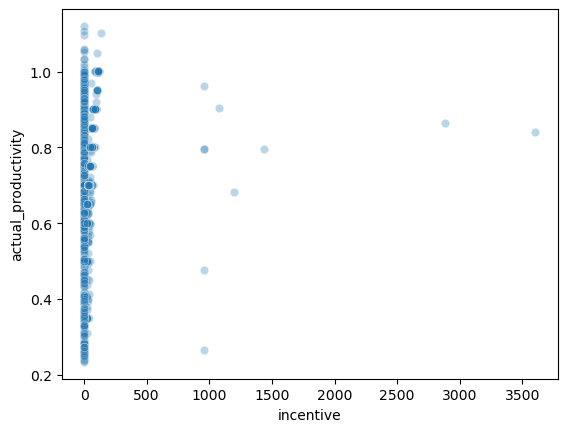

In [141]:
sns.scatterplot(data=df, x='incentive', y='actual_productivity', alpha=0.3)

We apply a logarithmic scale for impove visualization.

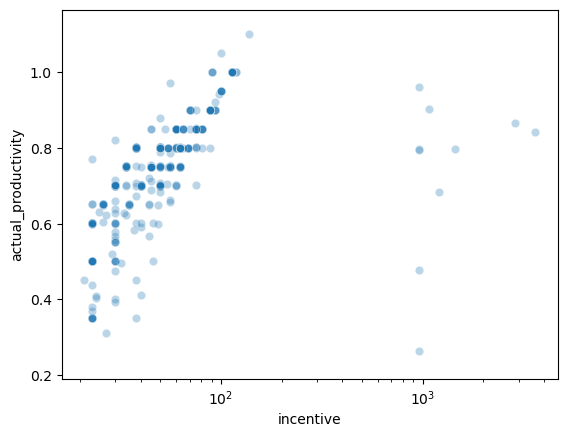

In [179]:
sns.scatterplot(data=df, x='incentive', y='actual_productivity', alpha=0.3)
plt.xscale('log')

In this scatter plot, there is a clear positive linear relationship between incentive and actual productivity. Additionally, there are some extreme values that appear to be of a different order of magnitude, which may indicate data entry errors or special cases.

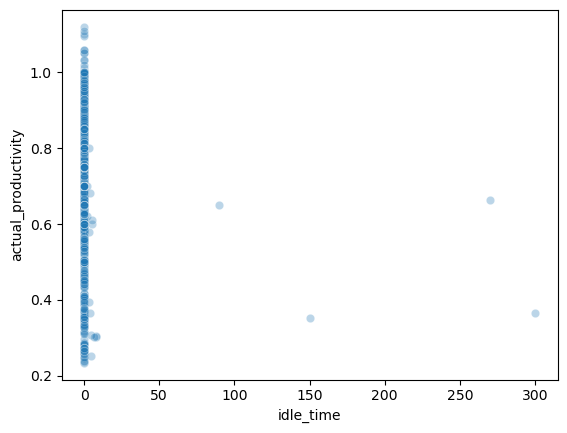

In [180]:
sns.scatterplot(data=df, x='idle_time', y='actual_productivity', alpha=0.3);

We apply a logarithmic scale for impove visualization.

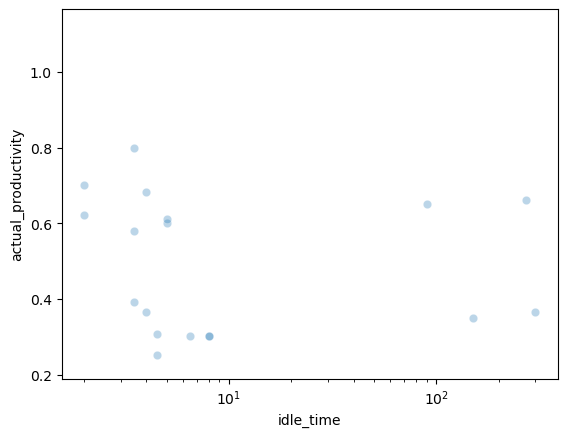

In [181]:
sns.scatterplot(data=df, x='idle_time', y='actual_productivity', alpha=0.3)

plt.xscale('log')

Whether using a logarithmic scale or not, the relationship remains unclear.

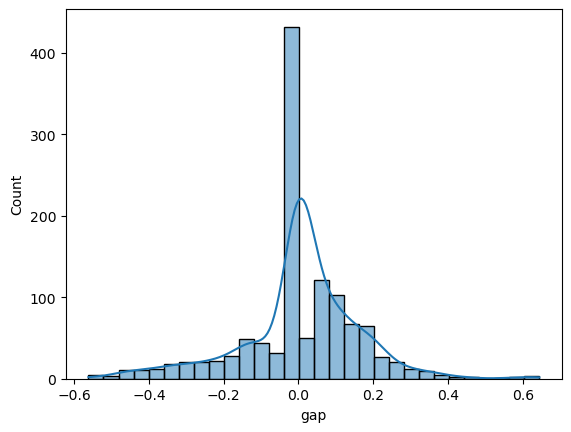

In [183]:
df['gap'] = df['actual_productivity'] - df['targeted_productivity']

sns.histplot(df['gap'],kde=True, bins=30);

The distribution of the productivity gap is approximately centered around zero, suggesting that, on average, actual productivity aligns with the targeted levels. Although slight asymmetry may be present, there is no strong evidence of systematic overestimation or underestimation in the targets.

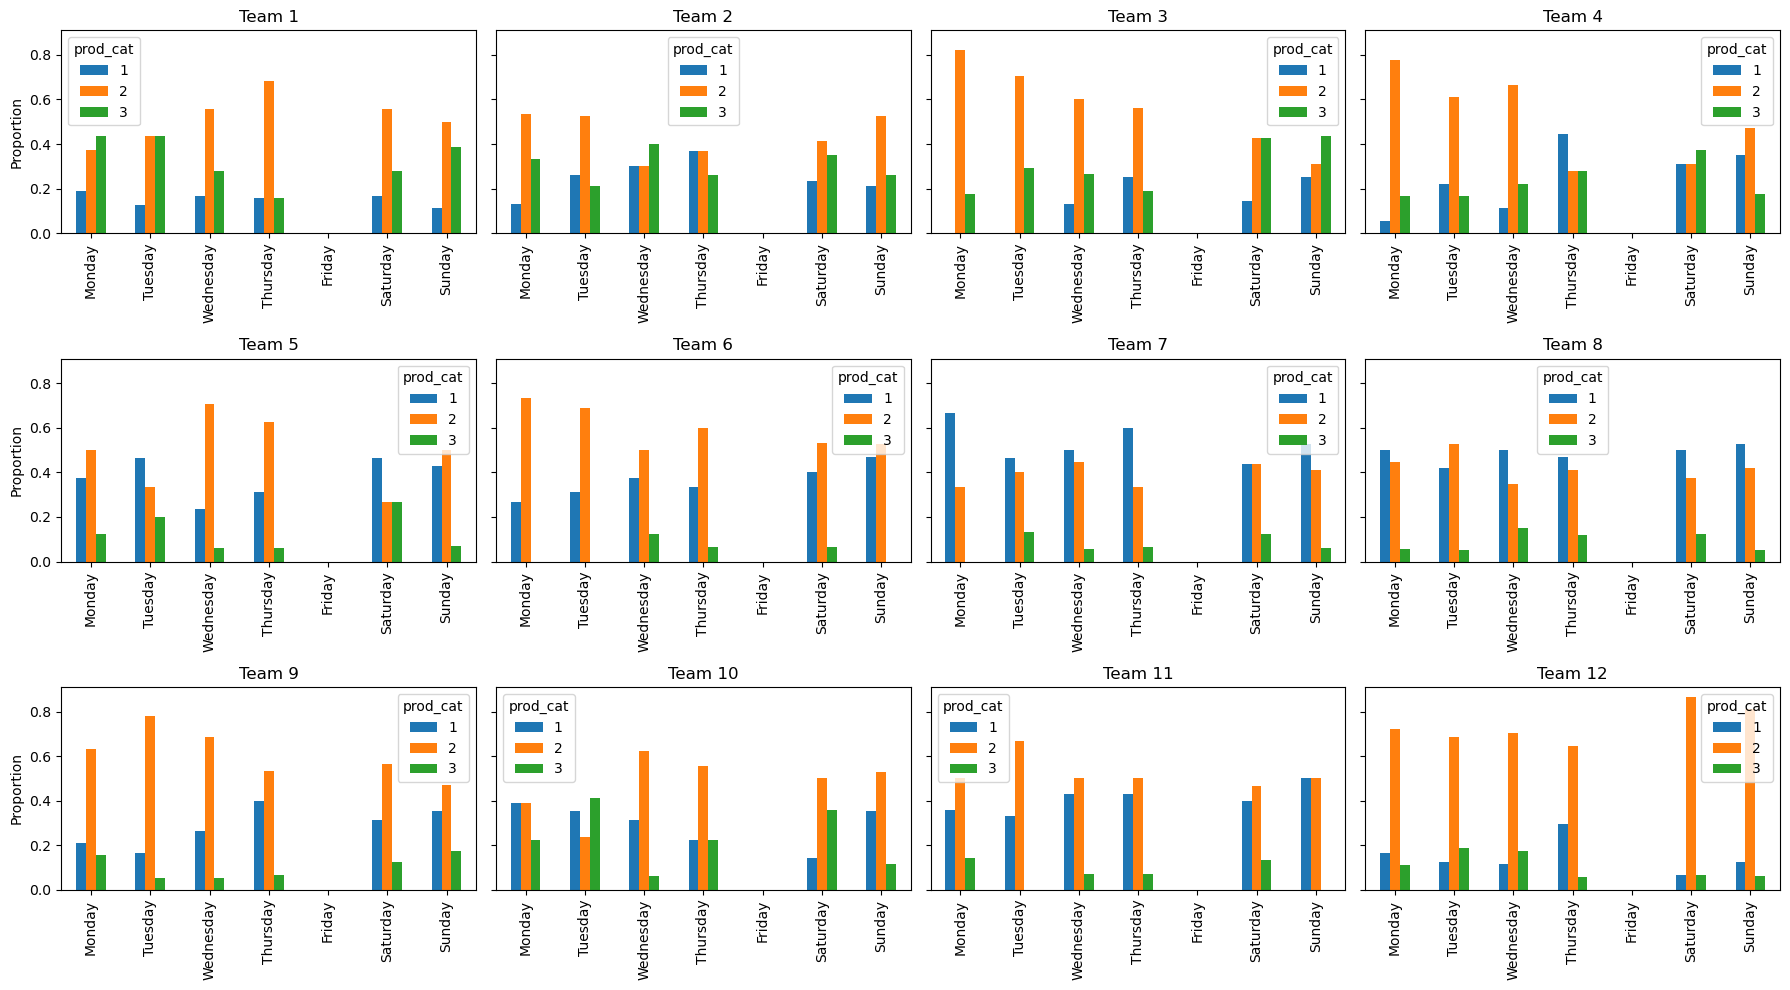

In [104]:
import matplotlib.pyplot as plt

teams = sorted(df['team'].unique())
order_days = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

fig, axes = plt.subplots(3, 4, figsize=(18, 10), sharey=True)
axes = axes.flatten()

for i, t in enumerate(teams):
    
    ax = axes[i]
    
    aux = summary[summary['team']==t]
    
    pivot = aux.pivot(index='day', columns='prod_cat', values='prop')
    
    pivot = pivot.reindex(order_days)
    
    pivot.plot(kind='bar', ax=ax)
    
    ax.set_title(f'Team {t}')
    ax.set_xlabel('')
    ax.set_ylabel('Proportion')

plt.tight_layout()
plt.show()

It's clear that most of teams has a productivity 2 as mayoritary output and some teams (5, 6, 7, 8, 9, 11) has more productivity 1 than 3 (which means: worst productivity)